In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.naive_bayes import GaussianNB


In [3]:
df = pd.read_csv('/workspaces/SML/SML /Exp 9/adult.csv',header=None)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
             'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

df.columns = col_names

df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='str')

In [5]:
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include = 'object').columns:
    df[col] = le.fit_transform(df[col])

/tmp/ipykernel_2343/3507697752.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include = 'object').columns:


In [8]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [9]:
#splitting the train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [10]:
from sklearn.preprocessing import StandardScaler
sc =  StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

GAUSSIAN

In [11]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [12]:
y_pred = gnb.predict(x_test)

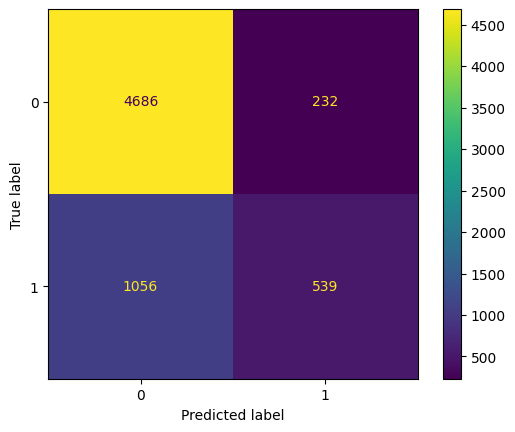

Confusion Matrix: [[4686  232]
 [1056  539]]
Accuracy: 0.8022416705051436
F1 Score: 0.4556213017751479


In [13]:
#making the confusion matrix
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,ConfusionMatrixDisplay,classification_report
cm = confusion_matrix(y_test,y_pred)
ac =accuracy_score(y_test,y_pred)
disp =ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
f1 = f1_score(y_test,y_pred)
print("Confusion Matrix:",cm)
print("Accuracy:",ac)

print("F1 Score:",f1)

In [14]:
cf = classification_report(y_test,y_pred)
print(cf)

              precision    recall  f1-score   support

           0       0.82      0.95      0.88      4918
           1       0.70      0.34      0.46      1595

    accuracy                           0.80      6513
   macro avg       0.76      0.65      0.67      6513
weighted avg       0.79      0.80      0.78      6513



BERNOULLI

In [15]:
from sklearn.naive_bayes import BernoulliNB
Ber = BernoulliNB()
Ber.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [16]:
y_pred = Ber.predict(x_test)

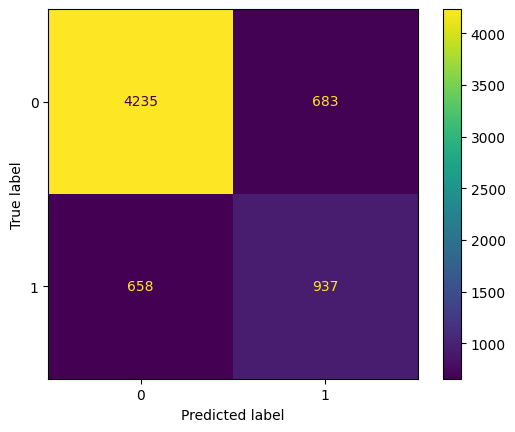

Accuracy Score: 0.7941040994933211
Confusion Matrix: [[4235  683]
 [ 658  937]]


In [17]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,ConfusionMatrixDisplay
ac = accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
print("Accuracy Score:",ac)
print("Confusion Matrix:",cm)


In [18]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.86      0.86      4918
           1       0.58      0.59      0.58      1595

    accuracy                           0.79      6513
   macro avg       0.72      0.72      0.72      6513
weighted avg       0.80      0.79      0.79      6513



MULTINOMIAL

In [19]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
x_train_mms=mms.fit_transform(x_train)

x_test_mms = mms.fit_transform(x_test)

In [20]:
from sklearn.naive_bayes import MultinomialNB
Mul = MultinomialNB()
Mul.fit(x_train_mms,y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [21]:
y_pred = Mul.predict(x_test)

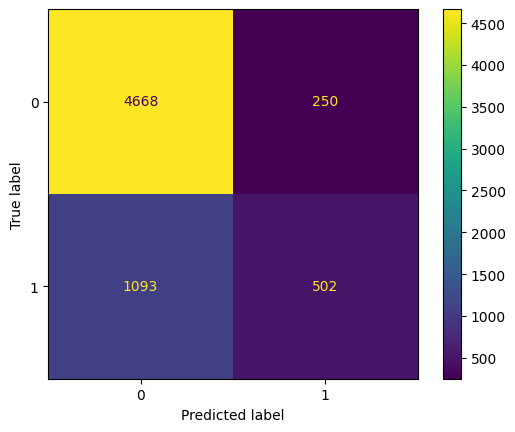

Confusion Matrix: [[4668  250]
 [1093  502]]
Accuracy: 0.7937970213419315
F1 Score: 0.4277801448657861


In [22]:
cm = confusion_matrix(y_test,y_pred)
ac =accuracy_score(y_test,y_pred)
disp =ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
f1 = f1_score(y_test,y_pred)
print("Confusion Matrix:",cm)
print("Accuracy:",ac)

print("F1 Score:",f1)

In [23]:
cf = classification_report(y_test,y_pred)
print(cf)

              precision    recall  f1-score   support

           0       0.81      0.95      0.87      4918
           1       0.67      0.31      0.43      1595

    accuracy                           0.79      6513
   macro avg       0.74      0.63      0.65      6513
weighted avg       0.78      0.79      0.76      6513



In [24]:
from sklearn.naive_bayes import ComplementNB
comp = ComplementNB()
comp.fit(x_train_mms,y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueOnly used in edge case with a single class in the training set.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. Not used.",None
,"norm norm: bool, default=FalseWhether or not a second normalization of the weights is performed. Thedefault behavior mirrors the implementations found in Mahout and Weka,which do not follow the full algorithm described in Table 9 of thepaper.",False


In [25]:
y_pred = comp.predict(x_test)

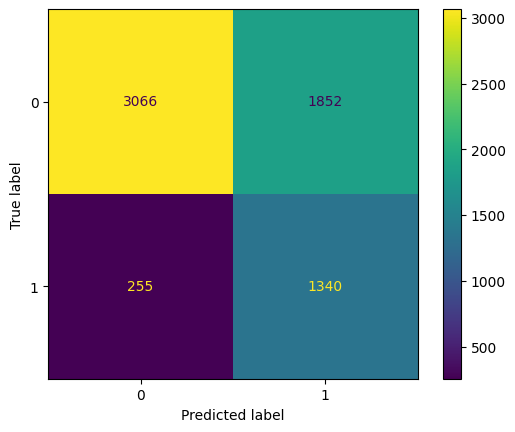

Confusion Matrix: [[3066 1852]
 [ 255 1340]]
Accuracy: 0.6764931675111315
F1 Score: 0.5598495926467516


In [26]:
cm = confusion_matrix(y_test,y_pred)
ac =accuracy_score(y_test,y_pred)
disp =ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
f1 = f1_score(y_test,y_pred)
print("Confusion Matrix:",cm)
print("Accuracy:",ac)

print("F1 Score:",f1)

In [27]:
cf = classification_report(y_test,y_pred)
print(cf)

              precision    recall  f1-score   support

           0       0.92      0.62      0.74      4918
           1       0.42      0.84      0.56      1595

    accuracy                           0.68      6513
   macro avg       0.67      0.73      0.65      6513
weighted avg       0.80      0.68      0.70      6513



CATEGORICAL

In [28]:
x_train_raw,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [29]:
from sklearn.naive_bayes import CategoricalNB
cat = CategoricalNB()
cat.fit(x_train_raw,y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


In [30]:
y_pred =cat.predict(x_test)

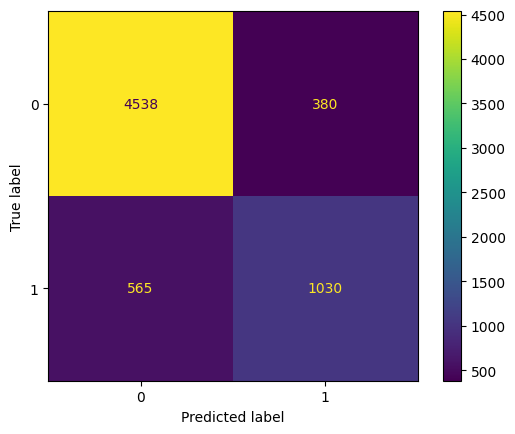

Confusion Matrix: [[4538  380]
 [ 565 1030]]
Accuracy: 0.8549055734684478
F1 Score: 0.6855241264559068


In [31]:

cm = confusion_matrix(y_test,y_pred)
ac =accuracy_score(y_test,y_pred)
disp =ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
f1 = f1_score(y_test,y_pred)
print("Confusion Matrix:",cm)
print("Accuracy:",ac)

print("F1 Score:",f1)

In [32]:
cf = classification_report(y_test,y_pred)
print(cf)

              precision    recall  f1-score   support

           0       0.89      0.92      0.91      4918
           1       0.73      0.65      0.69      1595

    accuracy                           0.85      6513
   macro avg       0.81      0.78      0.80      6513
weighted avg       0.85      0.85      0.85      6513



In [33]:
y_pred_prob = gnb.predict_proba(x_test)[0:10]

y_pred_prob

/workspaces/SML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [34]:
y_pred_prob_df = pd.DataFrame(data=y_pred_prob, columns=['Prob of - <=50K', 'Prob of - >50K'])

y_pred_prob_df

,Prob of - <=50K,Prob of - >50K
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
5,1.0,0.0
6,1.0,0.0
7,1.0,0.0
8,1.0,0.0
9,1.0,0.0


In [35]:
y_pred1 = gnb.predict_proba(x_test)[:, 1]

/workspaces/SML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


Text(0, 0.5, 'Frequency')

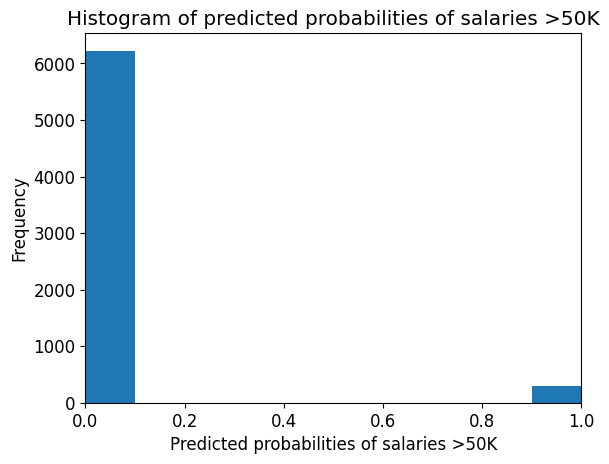

In [36]:
plt.rcParams['font.size'] = 12


# plot histogram with 10 bins
plt.hist(y_pred1, bins = 10)


# set the title of predicted probabilities
plt.title('Histogram of predicted probabilities of salaries >50K')


# set the x-axis limit
plt.xlim(0,1)
plt.xlabel('Predicted probabilities of salaries >50K')
plt.ylabel('Frequency')

/workspaces/SML/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


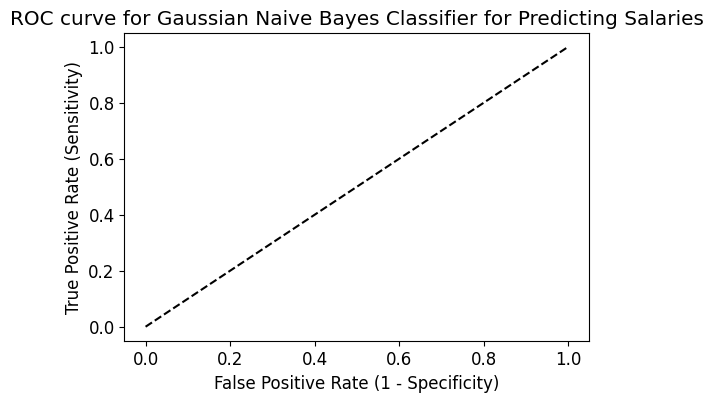

In [37]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred1, pos_label = '>50K')

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0,1], [0,1], 'k--' )

plt.rcParams['font.size'] = 12

plt.title('ROC curve for Gaussian Naive Bayes Classifier for Predicting Salaries')

plt.xlabel('False Positive Rate (1 - Specificity)')

plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()
